# DQN Variant Comparison — Tutorial Benchmark

Runs 7 DQN variants through the tiered tutorial curriculum and measures **epochs to mastery**.

| Variant | Key Change |
|---------|------------|
| **Baseline** | Double DQN + PER (existing) |
| **Munchausen** | Reward += α·τ·log π(a\|s) |
| **Spectral Norm** | Spectral-normalized backbone convolutions |
| **NoisyNet** | Parametric noise replaces ε-greedy |
| **Dueling** | V(s) + A(s,a) decomposition |
| **QR-DQN** | Quantile regression with fixed atoms |
| **IQN** | Implicit quantile networks with sampled τ |

In [1]:
import sys, os, time, random
import numpy as np
import torch

# Ensure project root is on path — works whether launched from
# the project root (`python -m notebook notebooks/...`) or
# from the notebooks/ directory (`jupyter notebook ...`).
_cwd = os.getcwd()
if os.path.basename(_cwd) == "notebooks":
    PROJECT_ROOT = os.path.abspath(os.path.join(_cwd, ".."))
elif os.path.isdir(os.path.join(_cwd, "simulation")):
    PROJECT_ROOT = _cwd
else:
    PROJECT_ROOT = os.path.abspath(os.path.join(_cwd, ".."))

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Project root: /home/franko/CT-DRL-MA
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 2060 SUPER


In [2]:
from simulation.rl.agent_registry import AGENT_REGISTRY, create_agent
from simulation.training.curriculum_trainer import (
    create_env_factory, build_agent_config,
)
from simulation.training.tutorial_runner import TutorialRunner

print(f"Available variants: {list(AGENT_REGISTRY.keys())}")

Available variants: ['baseline', 'munchausen', 'spectral_norm', 'noisynet', 'dueling', 'qrdqn', 'iqn', 'kitchen_sink']


In [3]:
# ── Configuration ──────────────────────────────────────────────────────

SEED = 42
MAX_EPOCHS = 700          # max tutorial epochs per variant
MASTERY_THRESHOLD = 0.9   # 90% pass rate over sliding window
WINDOW_SIZE = 20
MIN_EPOCHS = 10
LOG_EVERY = 25            # print progress every N epochs

# Early stopping: abort if not past this tier by this epoch
EARLY_STOP_TIER = 2       # must have mastered tier 2 ("Full chains")
EARLY_STOP_EPOCH = 120    # by epoch 120

# All 7 DQN algorithm variants (baseline CNN backbone for all)
VARIANTS = [
    "noisynet",
    "baseline",
    "munchausen",
    "spectral_norm",
    "dueling",
    "qrdqn",
    "iqn",
]

print(f"Will run {len(VARIANTS)} variants with max {MAX_EPOCHS} epochs each.")
print(f"Early stopping: must pass tier {EARLY_STOP_TIER} by epoch {EARLY_STOP_EPOCH}")

Will run 7 variants with max 700 epochs each.
Early stopping: must pass tier 2 by epoch 120


In [4]:
# ── Environment factory (shared across all variants) ──────────────────

env_factory = create_env_factory(
    rows=5, bays=58, tiers=5, tracks=7, split_factor=20,
)

# Base agent config (shared yard geometry + training defaults)
base_cfg = build_agent_config(
    rows=5, bays=58, tiers=5, split_factor=20, tracks=7,
)

print(f"Agent config device: {base_cfg.device}")
print(f"Replay buffer: {base_cfg.training.replay_size:,}")
print(f"Batch size: {base_cfg.training.batch_size}")
print(f"Gamma: {base_cfg.training.gamma}")

Agent config device: cuda
Replay buffer: 2,000
Batch size: 32
Gamma: 0.99


In [5]:
# ── Run all variants ──────────────────────────────────────────────────

import gc

results = {}

for variant_name in VARIANTS:
    print(f"\n{'='*70}")
    print(f"  VARIANT: {variant_name.upper()}")
    print(f"{'='*70}\n")

    # Seed everything for reproducibility
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    # Create agent (baseline CNN backbone for all DQN variants)
    # agent = create_agent(variant_name, base_cfg, backbone_variant="region_aware")
    agent = create_agent(variant_name, base_cfg)
    n_params = sum(p.numel() for p in agent.q_net.parameters())
    print(f"  Parameters: {n_params:,}")

    # Create runner with this agent
    runner = TutorialRunner(
        env_factory=env_factory,
        agent_or_config=agent,
        verbose=True,
    )

    # Train
    t0 = time.time()
    summary = runner.train_all(
        epochs=MAX_EPOCHS,
        mastery_threshold=MASTERY_THRESHOLD,
        window_size=WINDOW_SIZE,
        min_epochs=MIN_EPOCHS,
        log_every=LOG_EVERY,
        early_stop_check=lambda ep, tier: ep >= EARLY_STOP_EPOCH and tier < EARLY_STOP_TIER,
    )
    wall_time = time.time() - t0

    # Store results
    early_stopped = summary.get("early_stopped", False)
    results[variant_name] = {
        "epochs": summary["epochs_completed"],
        "mastered": summary["mastered"],
        "early_stopped": early_stopped,
        "current_tier": summary["current_tier"],
        "n_tiers": summary["n_tiers"],
        "pass_rates": summary["pass_rates"],
        "scenario_names": summary["scenario_names"],
        "wall_time_s": wall_time,
        "n_params": n_params,
    }

    status = "MASTERED" if summary["mastered"] else ("EARLY STOPPED" if early_stopped else "NOT MASTERED")
    print(f"\n  Result: {status} in {summary['epochs_completed']} epochs "
          f"({wall_time:.0f}s wall time)")
    print(f"  Tier reached: {summary['current_tier']}/{summary['n_tiers']}")

    # ── Aggressive GPU cleanup ──────────────────────────────────────
    agent.q_net.cpu()
    agent.target_net.cpu()
    agent.replay = None
    del agent, runner
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        allocated = torch.cuda.memory_allocated() / 1024**2
        reserved = torch.cuda.memory_reserved() / 1024**2
        print(f"  GPU cleanup: {allocated:.0f} MB allocated, {reserved:.0f} MB reserved")

print(f"\n{'='*70}")
print("  ALL VARIANTS COMPLETE")
print(f"{'='*70}")


  VARIANT: NOISYNET

  Parameters: 143,973

  Tutorial tiers (13 total):
    Tier 0: Primitives [S1, S2, S3, S4]
    Tier 1: Two-action chains [S5, S6, S26, S27]
    Tier 2: Full chains [S7, S8]
    Tier 3: Restack + load [S9, S10]
    Tier 4: Random generalize [S11, S12]
    Tier 5: Multi-step hard [S13, S14]
    Tier 6: Terminal truck [S25, S22, S23, S24]
    Tier 7: Multi-vehicle [S15, S16]
    Tier 8: Bidirectional train [S17]
    Tier 9: Concurrent ops [S18, S19]
    Tier 10: Full complexity [S20, S21]
    Tier 11: Full train ops [S28, S29]
    Tier 12: Cross-modal orchestration [S30, S31]



/home/franko/.cache/pypoetry/virtualenvs/ct-drl-ma-7RJlkqYG-py3.12/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator KernelDensity from version 1.5.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(



  Epoch 25/700 — Tier 0: Primitives
    ► Tier 0: Primitives
      [====================] 100.0% OK S1: park_truck
      [====================] 100.0% OK S2: train_import
      [--------------------]  0.0%    S3: yard_to_truck
      [====----------------] 20.0%    S4: yard_to_train
    🔒 Tier 1: Two-action chains
    🔒 Tier 2: Full chains
    🔒 Tier 3: Restack + load
    🔒 Tier 4: Random generalize
    🔒 Tier 5: Multi-step hard
    🔒 Tier 6: Terminal truck
    🔒 Tier 7: Multi-vehicle
    🔒 Tier 8: Bidirectional train
    🔒 Tier 9: Concurrent ops
    🔒 Tier 10: Full complexity
    🔒 Tier 11: Full train ops
    🔒 Tier 12: Cross-modal orchestration
    Average (active): 55.0% | Mastered: 2/31 | Graduated: 0 | ε=0.645

  Epoch 50/700 — Tier 0: Primitives
    ► Tier 0: Primitives
      [====================] 100.0% OK S1: park_truck
      [====================] 100.0% OK S2: train_import
      [======--------------] 30.0%    S3: yard_to_truck
      [===========---------] 55.0%    S4: yard_

/home/franko/.cache/pypoetry/virtualenvs/ct-drl-ma-7RJlkqYG-py3.12/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator KernelDensity from version 1.5.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(



  Epoch 25/700 — Tier 0: Primitives
    ► Tier 0: Primitives
      [====================] 100.0% OK S1: park_truck
      [====================] 100.0% OK S2: train_import
      [==------------------] 10.0%    S3: yard_to_truck
      [===-----------------] 15.0%    S4: yard_to_train
    🔒 Tier 1: Two-action chains
    🔒 Tier 2: Full chains
    🔒 Tier 3: Restack + load
    🔒 Tier 4: Random generalize
    🔒 Tier 5: Multi-step hard
    🔒 Tier 6: Terminal truck
    🔒 Tier 7: Multi-vehicle
    🔒 Tier 8: Bidirectional train
    🔒 Tier 9: Concurrent ops
    🔒 Tier 10: Full complexity
    🔒 Tier 11: Full train ops
    🔒 Tier 12: Cross-modal orchestration
    Average (active): 56.2% | Mastered: 2/31 | Graduated: 0 | ε=0.645

  Epoch 50/700 — Tier 0: Primitives
    ► Tier 0: Primitives
      [====================] 100.0% OK S1: park_truck
      [====================] 100.0% OK S2: train_import
      [=============-------] 65.0%    S3: yard_to_truck
      [==================--] 90.0% OK S4: yard_

...


  Epoch 25/700 — Tier 0: Primitives
    ► Tier 0: Primitives
      [====================] 100.0% OK S1: park_truck
      [====================] 100.0% OK S2: train_import
      [=====---------------] 25.0%    S3: yard_to_truck
      [=============-------] 65.0%    S4: yard_to_train
    🔒 Tier 1: Two-action chains
    🔒 Tier 2: Full chains
    🔒 Tier 3: Restack + load
    🔒 Tier 4: Random generalize
    🔒 Tier 5: Multi-step hard
    🔒 Tier 6: Terminal truck
    🔒 Tier 7: Multi-vehicle
    🔒 Tier 8: Bidirectional train
    🔒 Tier 9: Concurrent ops
    🔒 Tier 10: Full complexity
    🔒 Tier 11: Full train ops
    🔒 Tier 12: Cross-modal orchestration
    Average (active): 72.5% | Mastered: 2/31 | Graduated: 0 | ε=0.645

  Epoch 50/700 — Tier 0: Primitives
    ► Tier 0: Primitives
      [====================] 100.0% OK S1: park_truck
      [====================] 100.0% OK S2: train_import
      [==========----------] 50.0%    S3: yard_to_truck
      [======--------------] 30.0%    S4: yard_

/home/franko/.cache/pypoetry/virtualenvs/ct-drl-ma-7RJlkqYG-py3.12/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator KernelDensity from version 1.5.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(



  Epoch 25/700 — Tier 0: Primitives
    ► Tier 0: Primitives
      [====================] 100.0% OK S1: park_truck
      [====================] 100.0% OK S2: train_import
      [=-------------------]  5.0%    S3: yard_to_truck
      [========------------] 40.0%    S4: yard_to_train
    🔒 Tier 1: Two-action chains
    🔒 Tier 2: Full chains
    🔒 Tier 3: Restack + load
    🔒 Tier 4: Random generalize
    🔒 Tier 5: Multi-step hard
    🔒 Tier 6: Terminal truck
    🔒 Tier 7: Multi-vehicle
    🔒 Tier 8: Bidirectional train
    🔒 Tier 9: Concurrent ops
    🔒 Tier 10: Full complexity
    🔒 Tier 11: Full train ops
    🔒 Tier 12: Cross-modal orchestration
    Average (active): 61.3% | Mastered: 2/31 | Graduated: 0 | ε=0.645

  Epoch 50/700 — Tier 0: Primitives
    ► Tier 0: Primitives
      [====================] 100.0% OK S1: park_truck
      [====================] 100.0% OK S2: train_import
      [==============------] 70.0%    S3: yard_to_truck
      [========------------] 40.0%    S4: yard_

/home/franko/.cache/pypoetry/virtualenvs/ct-drl-ma-7RJlkqYG-py3.12/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator KernelDensity from version 1.5.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(



  Epoch 25/700 — Tier 0: Primitives
    ► Tier 0: Primitives
      [====================] 100.0% OK S1: park_truck
      [====================] 100.0% OK S2: train_import
      [--------------------]  0.0%    S3: yard_to_truck
      [===-----------------] 15.0%    S4: yard_to_train
    🔒 Tier 1: Two-action chains
    🔒 Tier 2: Full chains
    🔒 Tier 3: Restack + load
    🔒 Tier 4: Random generalize
    🔒 Tier 5: Multi-step hard
    🔒 Tier 6: Terminal truck
    🔒 Tier 7: Multi-vehicle
    🔒 Tier 8: Bidirectional train
    🔒 Tier 9: Concurrent ops
    🔒 Tier 10: Full complexity
    🔒 Tier 11: Full train ops
    🔒 Tier 12: Cross-modal orchestration
    Average (active): 53.8% | Mastered: 2/31 | Graduated: 0 | ε=0.645

  Epoch 50/700 — Tier 0: Primitives
    ► Tier 0: Primitives
      [====================] 100.0% OK S1: park_truck
      [====================] 100.0% OK S2: train_import
      [======--------------] 30.0%    S3: yard_to_truck
      [======--------------] 30.0%    S4: yard_

In [6]:
# ── Summary table ─────────────────────────────────────────────────────

import pandas as pd

rows = []
for name, r in results.items():
    avg_rate = np.mean(list(r["pass_rates"].values()))
    rows.append({
        "Variant": name,
        "Epochs": r["epochs"],
        "Mastered": "Yes" if r["mastered"] else "No",
        "Tier": f"{r['current_tier']}/{r['n_tiers']}",
        "Avg Pass Rate": f"{avg_rate:.1%}",
        "Wall Time (s)": f"{r['wall_time_s']:.0f}",
        "Parameters": f"{r['n_params']:,}",
    })

df_summary = pd.DataFrame(rows)
df_summary = df_summary.sort_values("Epochs").reset_index(drop=True)
df_summary

,Variant,Epochs,Mastered,Tier,Avg Pass Rate,Wall Time (s),Parameters
0,qrdqn,120,No,0/13,9.7%,596,"145,953"
1,iqn,120,No,0/13,9.7%,758,"152,487"
2,dueling,120,No,0/13,8.4%,624,"148,133"
3,munchausen,317,Yes,13/13,97.7%,1649,"143,907"
4,baseline,320,Yes,13/13,98.9%,1561,"143,907"
5,spectral_norm,343,Yes,13/13,99.2%,1627,"143,907"
6,noisynet,522,Yes,13/13,97.4%,6877,"143,973"


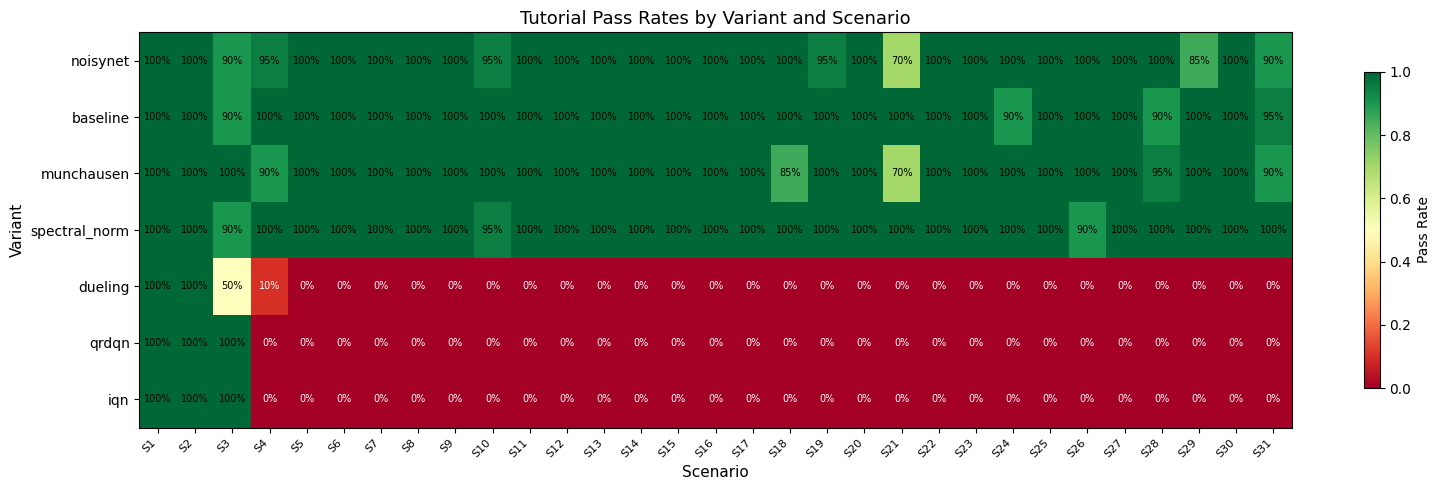

Saved: variant_heatmap.png


In [7]:
# ── Per-scenario pass-rate heatmap ────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib

# Build matrix: variants x scenarios
variant_names = list(results.keys())
# Get scenario IDs in order from any variant
first = next(iter(results.values()))
scenario_ids = sorted(first["pass_rates"].keys())
scenario_labels = [f"S{sid}" for sid in scenario_ids]

matrix = np.zeros((len(variant_names), len(scenario_ids)))
for i, vname in enumerate(variant_names):
    for j, sid in enumerate(scenario_ids):
        matrix[i, j] = results[vname]["pass_rates"].get(sid, 0.0)

fig, ax = plt.subplots(figsize=(16, 5))
cmap = matplotlib.colormaps["RdYlGn"]
im = ax.imshow(matrix, aspect="auto", cmap=cmap, vmin=0, vmax=1)

ax.set_xticks(range(len(scenario_ids)))
ax.set_xticklabels(scenario_labels, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(variant_names)))
ax.set_yticklabels(variant_names, fontsize=10)

# Annotate cells
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        val = matrix[i, j]
        color = "white" if val < 0.5 else "black"
        ax.text(j, i, f"{val:.0%}", ha="center", va="center",
                fontsize=7, color=color)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Pass Rate", fontsize=10)

ax.set_title("Tutorial Pass Rates by Variant and Scenario", fontsize=13)
ax.set_xlabel("Scenario", fontsize=11)
ax.set_ylabel("Variant", fontsize=11)

plt.tight_layout()
plt.savefig("variant_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: variant_heatmap.png")

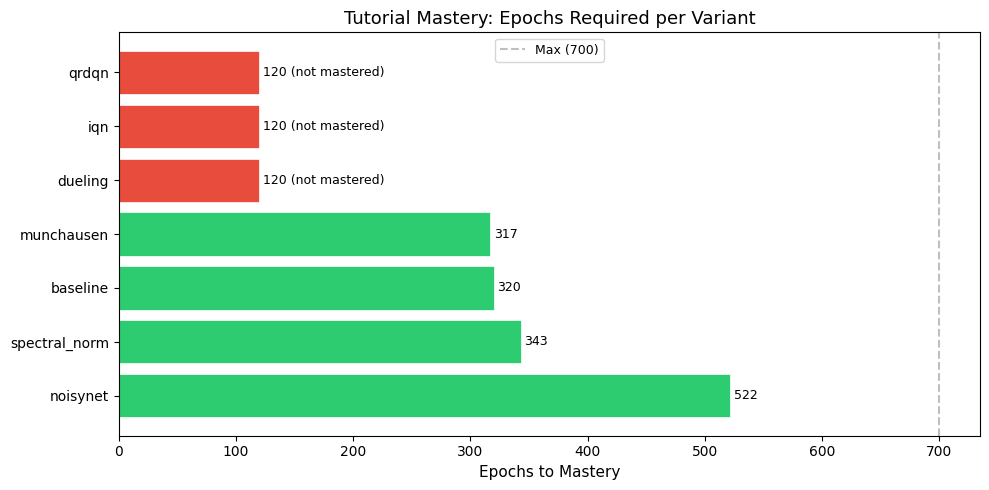

Saved: variant_epochs.png


In [8]:
# ── Epochs-to-mastery bar chart ──────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))

names = [r["Variant"] for _, r in df_summary.iterrows()]
epochs = [int(r["Epochs"]) for _, r in df_summary.iterrows()]
mastered = [r["Mastered"] == "Yes" for _, r in df_summary.iterrows()]
colors = ["#2ecc71" if m else "#e74c3c" for m in mastered]

bars = ax.barh(names, epochs, color=colors, edgecolor="white", linewidth=0.5)

for bar, ep, m in zip(bars, epochs, mastered):
    label = f"{ep}" if m else f"{ep} (not mastered)"
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2,
            label, va="center", fontsize=9)

ax.set_xlabel("Epochs to Mastery", fontsize=11)
ax.set_title("Tutorial Mastery: Epochs Required per Variant", fontsize=13)
ax.axvline(x=MAX_EPOCHS, color="gray", linestyle="--", alpha=0.5, label=f"Max ({MAX_EPOCHS})")
ax.legend(fontsize=9)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("variant_epochs.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: variant_epochs.png")

In [9]:
# ── Save raw results to JSON ─────────────────────────────────────────

import json

# Convert int keys to strings for JSON
serializable = {}
for vname, r in results.items():
    serializable[vname] = {
        **r,
        "pass_rates": {str(k): v for k, v in r["pass_rates"].items()},
        "scenario_names": {str(k): v for k, v in r["scenario_names"].items()},
    }

with open("variant_results.json", "w") as f:
    json.dump(serializable, f, indent=2)

print("Saved: variant_results.json")
print("\nDone! Check the summary table and heatmap above.")

Saved: variant_results.json

Done! Check the summary table and heatmap above.
